In [4]:
import sagemaker
from sagemaker.sklearn.processing import SKLearnProcessor
from sagemaker.processing import ProcessingInput, ProcessingOutput

# 1. SETUP: Hardware and Permissions
role = "arn:aws:iam::962573741074:role/pricing-project-SageMakerExecutionRole-9SRscle4Htbr"
bucket = "pricing-project-data-962573741074-v2"

# FIX: Tell SageMaker to use your specific bucket for internal script storage
sess = sagemaker.Session(default_bucket=bucket) 

print(f"Using role: {role}")
print(f"Using bucket: {bucket}")

# 2. THE PROCESSOR (No changes here)
sklearn_processor = SKLearnProcessor(
    framework_version='1.2-1',
    role=role,
    instance_type='ml.t3.medium',
    instance_count=1,
    base_job_name='pricing-feature-engineering',
    sagemaker_session=sess # Ensure it uses the session with your bucket
)

# 3. THE RUN (No changes here)
print("Starting Processing Job... This will take a few minutes.")
sklearn_processor.run(
    code='processing.py', 
    inputs=[
        ProcessingInput(
            source=f's3://{bucket}/raw/baseline/', 
            destination='/opt/ml/processing/input',
            input_name='baseline_data'
        )
    ],
    outputs=[
        ProcessingOutput(
            source='/opt/ml/processing/output/train',
            destination=f's3://{bucket}/processed/train',
            output_name='processed_features'
        )
    ]
)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
Using role: arn:aws:iam::962573741074:role/pricing-project-SageMakerExecutionRole-9SRscle4Htbr
Using bucket: pricing-project-data-962573741074-v2
Starting Processing Job... This will take a few minutes.


INFO:sagemaker:Creating processing-job with name pricing-feature-engineering-2026-03-28-05-44-01-373


...............Processed 100 SKUs. Target Lift identified.



In [5]:
import pandas as pd

role = "arn:aws:iam::962573741074:role/pricing-project-SageMakerExecutionRole-9SRscle4Htbr"
bucket = "pricing-project-data-962573741074-v2"

# 1. Load the data
features_s3_path = f"s3://{bucket}/processed/train/features.csv"
df_features = pd.read_csv(features_s3_path)

print(f"✅ Successfully loaded data with columns: {list(df_features.columns)}")
print("-" * 30)

# 2. Dynamic Display: We show the first 5 columns + the ones we know exist
# This avoids the KeyError by not forcing 'base_price'
cols_to_show = [c for c in df_features.columns if c in ['sku_id', 'price', 'base_price', 'ctd_ratio', 'btd_ratio', 'target_adjustment']]
display(df_features[cols_to_show].head(10))

# 3. Validation Logic
if 'target_adjustment' in df_features.columns:
    discounts = df_features[df_features['target_adjustment'] < 0]
    print(f"\n💡 Analysis: Found {len(discounts)} products recommended for a -15% adjustment.")
else:
    print("\n❌ Warning: 'target_adjustment' column not found. Check processing.py logic.")

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)
INFO:botocore.credentials:Found credentials from IAM Role: BaseNotebookInstanceEc2InstanceRole


✅ Successfully loaded data with columns: ['sku_id', 'product_name', 'category', 'base_cost', 'current_msrp', 'inventory_level', 'views', 'carts', 'buys', 'ctd_ratio', 'btd_ratio', 'event_time', 'target_adjustment']
------------------------------


,sku_id,ctd_ratio,btd_ratio,target_adjustment
0,ELEC-1000,0.110266,0.152091,0.00
1,ELEC-1001,0.076596,0.140426,0.00
2,ELEC-1002,0.108597,0.108597,0.00
3,ELEC-1003,0.100402,0.132530,0.00
4,ELEC-1004,0.090129,0.008584,-0.15
5,ELEC-1005,0.097276,0.007782,-0.15
6,ELEC-1006,0.115538,0.127490,0.00
7,ELEC-1007,0.089494,0.136187,0.00
8,ELEC-1008,0.088462,0.003846,-0.15
9,ELEC-1009,0.109649,0.122807,0.00



💡 Analysis: Found 25 products recommended for a -15% adjustment.


In [6]:
import sagemaker
import time
import pandas as pd
from sagemaker.feature_store.feature_group import FeatureGroup

# 1. SETUP
role = "arn:aws:iam::962573741074:role/pricing-project-SageMakerExecutionRole-9SRscle4Htbr"
bucket = "pricing-project-data-962573741074-v2"
sess = sagemaker.Session(default_bucket=bucket)

# Load your validated features
features_s3_path = f"s3://{bucket}/processed/train/features.csv"
df_features = pd.read_csv(features_s3_path)
df_features['event_time'] = df_features['event_time'].astype(float)

# 2. DEFINE FEATURE GROUP
# Using a unique name to avoid "AlreadyExists" errors
feature_group_name = f"pricing-sku-features-{int(time.time())}"
feature_group = FeatureGroup(name=feature_group_name, sagemaker_session=sess)
feature_group.load_feature_definitions(data_frame=df_features)

# 3. CREATE (Updated for SDK v2.148+)
print(f"Creating Feature Group: {feature_group_name}...")

feature_group.create(
    s3_uri=f"s3://{bucket}/feature-store", # Position 1: The Offline Store location
    record_identifier_name="sku_id",       # Position 2
    event_time_feature_name="event_time",   # Position 3
    role_arn=role,
    enable_online_store=True
)

# 4. WAIT FOR CREATION
def wait_for_creation(fg):
    status = fg.describe().get("FeatureGroupStatus")
    while status == "Creating":
        print("Waiting for Feature Group to be READY...")
        time.sleep(5)
        status = fg.describe().get("FeatureGroupStatus")
    print(f"Status: {status}")

wait_for_creation(feature_group)

# 5. INGEST
print("\nIngesting data into Feature Store...")
feature_group.ingest(data_frame=df_features, max_workers=3, wait=True)

print(f"✅ SUCCESS! 100 SKUs (including {len(df_features[df_features['target_adjustment'] < 0])} adjustment signals) are live.")

INFO:botocore.credentials:Found credentials from IAM Role: BaseNotebookInstanceEc2InstanceRole
INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


Creating Feature Group: pricing-sku-features-1774676978...


INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


Waiting for Feature Group to be READY...


INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


...

Waiting for Feature Group to be READY...


INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


Status: Created

Ingesting data into Feature Store...


INFO:botocore.credentials:Found credentials from IAM Role: BaseNotebookInstanceEc2InstanceRole
INFO:botocore.credentials:Found credentials from IAM Role: BaseNotebookInstanceEc2InstanceRole
INFO:botocore.credentials:Found credentials from IAM Role: BaseNotebookInstanceEc2InstanceRole
INFO:sagemaker.feature_store.feature_group:Started ingesting index 0 to 34
INFO:sagemaker.feature_store.feature_group:Started ingesting index 68 to 100
INFO:sagemaker.feature_store.feature_group:Started ingesting index 34 to 68
INFO:sagemaker.feature_store.feature_group:Successfully ingested row 0 to 34
INFO:sagemaker.feature_store.feature_group:Successfully ingested row 68 to 100
INFO:sagemaker.feature_store.feature_group:Successfully ingested row 34 to 68


✅ SUCCESS! 100 SKUs (including 25 adjustment signals) are live.


In [7]:
import pandas as pd
import boto3
import io

# 1. SETUP: Point to your processed data
# Make sure this matches your 'train_input' path
s3_path = f"s3://{bucket}/processed/train/features.csv"
print(f"Reading preview from: {s3_path}")

# 2. READ: Use pandas to grab a quick look
# Note: SageMaker roles allow pandas to read s3:// paths directly
try:
    df_preview = pd.read_csv(s3_path)
    print("✅ Successfully loaded data preview!")
    display(df_preview.head())
    print(f"\nAvailable Columns: {df_preview.columns.tolist()}")
except Exception as e:
    print(f"❌ Error: Could not read the file. Make sure the Processing Job finished. {e}")


Reading preview from: s3://pricing-project-data-962573741074-v2/processed/train/features.csv
✅ Successfully loaded data preview!


,sku_id,product_name,category,base_cost,current_msrp,inventory_level,views,carts,buys,ctd_ratio,btd_ratio,event_time,target_adjustment
0,ELEC-1000,Cameras Device 0,Cameras,762.05,1598.26,208,263,29,40,0.110266,0.152091,1.774677e+09,0.00
1,ELEC-1001,Smart Home Device 1,Smart Home,150.13,280.94,350,235,18,33,0.076596,0.140426,1.774677e+09,0.00
2,ELEC-1002,Peripherals Device 2,Peripherals,696.96,1422.68,171,221,24,24,0.108597,0.108597,1.774677e+09,0.00
3,ELEC-1003,Peripherals Device 3,Peripherals,45.85,101.21,433,249,25,33,0.100402,0.132530,1.774677e+09,0.00
4,ELEC-1004,Computers Device 4,Computers,170.01,319.76,479,233,21,2,0.090129,0.008584,1.774677e+09,-0.15



Available Columns: ['sku_id', 'product_name', 'category', 'base_cost', 'current_msrp', 'inventory_level', 'views', 'carts', 'buys', 'ctd_ratio', 'btd_ratio', 'event_time', 'target_adjustment']


In [17]:
import sagemaker
from sagemaker.xgboost.estimator import XGBoost
from sagemaker.inputs import TrainingInput

# 1. SETUP
role = "arn:aws:iam::962573741074:role/pricing-project-SageMakerExecutionRole-9SRscle4Htbr"
bucket = "pricing-project-data-962573741074-v2"
sess = sagemaker.Session()

# 2. DEFINE THE HIGH-DEFINITION ESTIMATOR
# We are increasing rounds and depth to get nuanced price adjustments
xgb_estimator = XGBoost(
    entry_point='train.py',
    framework_version='1.7-1',
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    output_path=f's3://{bucket}/models',
    sagemaker_session=sess,
    hyperparameters={
        'max_depth': 8,              # Was 5: Allows deeper "logic trees" for SKU nuances
        'eta': 0.05,                 # Was 0.2: Lower learning rate for more precise convergence
        'objective': 'reg:squarederror',
        'num_round': 300,            # Was 50: Gives the model much more time to learn patterns
        'subsample': 0.8,            # Uses 80% of data per tree to prevent "Lazy Brain"
        'verbosity': 1
    }
)

# 3. POINT TO YOUR TRAINING DATA
train_input = TrainingInput(
    s3_data=f"s3://{bucket}/processed/train/features.csv",
    content_type='csv'
)

print("🚀 High-Definition Estimator Ready!")
print("Next step: Run xgb_estimator.fit({'train': train_input})")

INFO:sagemaker.image_uris:Ignoring unnecessary Python version: py3.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: ml.m5.xlarge.


🚀 High-Definition Estimator Ready!
Next step: Run xgb_estimator.fit({'train': train_input})


In [18]:
# 4. LAUNCH!
print("🚀 Sending training job to SageMaker...")

# This will bundle your NEW train.py into the model artifact
xgb_estimator.fit({'train': train_input})

print("\n🏆 Training job completed successfully!")

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-03-28-06-21-36-902


🚀 Sending training job to SageMaker...
2026-03-28 06:21:37 Starting - Starting the training job...
2026-03-28 06:22:00 Starting - Preparing the instances for training...
2026-03-28 06:22:22 Downloading - Downloading input data...
2026-03-28 06:22:47 Downloading - Downloading the training image...../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-28 06:23:50.359 ip-10-2-76-74.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-03-28 06:23:50.446 ip-10-2-76-74.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-03-28:06:23:50:INFO] Imported framework sagemaker_xgboost_container.training
[2026-03-28:06:23:50:INFO] No GPUs detected (normal

In [ ]:
## Serverless Inference

In [ ]:
## if an endpoint exists delete this one first

In [19]:
try:
    predictor.delete_endpoint()
    print("🗑️ Old endpoint deleted successfully.")
except Exception as e:
    print(f"⚠️ Note: {e}")

INFO:sagemaker:Deleting endpoint configuration with name: sagemaker-xgboost-2026-03-28-06-02-44-126
INFO:sagemaker:Deleting endpoint with name: sagemaker-xgboost-2026-03-28-06-02-44-126


🗑️ Old endpoint deleted successfully.


In [20]:
from sagemaker.serverless import ServerlessInferenceConfig
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import JSONDeserializer

# 1. Define Serverless Settings (Pay-per-use)
serverless_config = ServerlessInferenceConfig(
    memory_size_in_mb=2048,
    max_concurrency=5
)

# 2. Deploy with the "Translators" attached
print("📡 Activating the Pricing AI Bridge...")
predictor = xgb_estimator.deploy(
    serverless_inference_config=serverless_config,
    serializer=CSVSerializer(),       # Turns your list into CSV for the model
    deserializer=JSONDeserializer()    # Turns the model's response back into a list
)

print("\n✅ LIVE: The endpoint passed the health check!")

📡 Activating the Pricing AI Bridge...


INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-03-28-06-28-18-497
INFO:sagemaker:Creating endpoint-config with name sagemaker-xgboost-2026-03-28-06-28-18-497
INFO:sagemaker:Creating endpoint with name sagemaker-xgboost-2026-03-28-06-28-18-497


-----!
✅ LIVE: The endpoint passed the health check!


In [21]:
# --- 10 STRATEGIC SCENARIOS ---
# [Name, CTD (Interest), BTD (Conversion), Stock]
scenarios = [
    ("Dead Stock (Liquidation)", 0.001, 0.0001, 10000), # Expect: Deepest Discount
    ("Viral Flop (High/Low)",    0.600, 0.0010, 800),   # Expect: High Discount
    ("Overstocked Classic",      0.050, 0.0500, 2500),  # Expect: Moderate Discount
    ("Slow Mover (Average)",     0.020, 0.0200, 500),   # Expect: Small Discount
    ("Hidden Gem (Low/High)",    0.010, 0.2500, 60),    # Expect: ~0% (High buy rate saves it)
    ("Stable Essential",         0.030, 0.0300, 15),    # Expect: 0% (Low stock risk)
    ("Superstar (Peak)",         0.950, 0.9000, 2),     # Expect: 0% 
    ("Clickbait Item",           0.850, 0.0050, 400),   # Expect: Significant Discount
    ("New Launch (Testing)",     0.020, 0.0100, 150),   # Expect: Tiny Adjustment
    ("Warehouse Emergency",      0.001, 0.0010, 7500)   # Expect: Very Deep Discount
]

print(f"{'SCENARIO':<25} | {'STOCK':<8} | {'ADJUSTMENT'}")
print("-" * 55)

unique_values = set()

for name, ctd, btd, stock in scenarios:
    try:
        # We just pass the list; the 'predictor' handles the CSV conversion automatically now
        res = predictor.predict([ctd, btd, stock])
        
        # Flatten the response (peel the onion)
        val = res
        while isinstance(val, list): val = val[0]
        val = float(val)
        
        unique_values.add(round(val, 4))
        print(f"{name:<25} | {stock:<8} | {val:>10.2%}")
        
    except Exception as e:
        print(f"❌ Error with {name}: {e}")

print("-" * 55)
print(f"📊 Nuance Check: {len(unique_values)} different price points out of 10.")

if len(unique_values) > 5:
    print("✅ SUCCESS: The model is providing customized pricing!")
else:
    print("⚠️ WARNING: The model is still 'clumping' answers. Check your training data.")

SCENARIO                  | STOCK    | ADJUSTMENT
-------------------------------------------------------
Dead Stock (Liquidation)  | 10000    |    -14.98%
Viral Flop (High/Low)     | 800      |    -14.98%
Overstocked Classic       | 2500     |    -14.98%
Slow Mover (Average)      | 500      |    -14.98%
Hidden Gem (Low/High)     | 60       |     -0.01%
Stable Essential          | 15       |    -14.98%
Superstar (Peak)          | 2        |     -0.01%
Clickbait Item            | 400      |    -14.98%
New Launch (Testing)      | 150      |    -14.98%
Warehouse Emergency       | 7500     |    -14.98%
-------------------------------------------------------
📊 Nuance Check: 2 different price points out of 10.
⚠️ WARNING: The model is still 'clumping' answers. Check your training data.


In [22]:
# Zero interest, Massive stock
get_prediction("Dead Item", 0.0001, 0.0001, 5000)

# Massive interest, Zero stock
get_prediction("Superstar", 0.99, 0.99, 1)

--- 📦 SKU: Dead Item ---
Inputs: [CTD: 0.0%, BTD: 0.0%, Stock: 5000]
Result: -14.98% price adjustment
💡 Insight: High inventory/Low interest. Discount recommended.
----------------------------------------
--- 📦 SKU: Superstar ---
Inputs: [CTD: 99.0%, BTD: 99.0%, Stock: 1]
Result: -0.01% price adjustment
💡 Insight: Stable performance. Maintain price.
----------------------------------------


-5.617296847049147e-05

In [ ]:
## delete Serverless

In [23]:
try:
    predictor.delete_endpoint()
    print("🗑️ Old endpoint deleted successfully.")
except Exception as e:
    print(f"⚠️ Note: {e}")

INFO:sagemaker:Deleting endpoint configuration with name: sagemaker-xgboost-2026-03-28-06-28-18-497
INFO:sagemaker:Deleting endpoint with name: sagemaker-xgboost-2026-03-28-06-28-18-497


🗑️ Old endpoint deleted successfully.


In [25]:
import boto3
sm_client = boto3.client('sagemaker')

# List all feature groups
groups = sm_client.list_feature_groups()

if not groups['FeatureGroupSummaries']:
    print("∅ No Feature Groups found. You are starting with a completely clean slate!")
else:
    print("📂 Existing Feature Groups:")
    for group in groups['FeatureGroupSummaries']:
        print(f" - {group['FeatureGroupName']}")

📂 Existing Feature Groups:
 - pricing-sku-features-1774676978
 - pricing-sku-features-1774645913
 - pricing-sku-features-1774621339


In [26]:
# Check the latest one
latest_group = "pricing-sku-features-1774676978"
res = sm_client.describe_feature_group(FeatureGroupName=latest_group)
print(f"Creation Time: {res['CreationTime']}")

Creation Time: 2026-03-28 05:49:38.794000+00:00


In [27]:
import boto3

# 1. Initialize the SageMaker Client
sm_client = boto3.client('sagemaker')

# 2. Define your latest group name
latest_feature_group_name = "pricing-sku-features-1774676978"

try:
    # 3. Request the full metadata
    response = sm_client.describe_feature_group(FeatureGroupName=latest_feature_group_name)
    
    print(f"📋 FEATURE GROUP: {latest_feature_group_name}")
    print(f"📅 Created On: {response['CreationTime']}")
    print(f"🚦 Status: {response['FeatureGroupStatus']}")
    print("-" * 50)
    print(f"{'FEATURE NAME':<25} | {'TYPE'}")
    print("-" * 50)
    
    # 4. Loop through the definitions
    for feature in response['FeatureDefinitions']:
        print(f"{feature['FeatureName']:<25} | {feature['FeatureType']}")
        
except Exception as e:
    print(f"❌ Could not find group: {e}")

📋 FEATURE GROUP: pricing-sku-features-1774676978
📅 Created On: 2026-03-28 05:49:38.794000+00:00
🚦 Status: Created
--------------------------------------------------
FEATURE NAME              | TYPE
--------------------------------------------------
sku_id                    | String
product_name              | String
category                  | String
base_cost                 | Fractional
current_msrp              | Fractional
inventory_level           | Integral
views                     | Integral
carts                     | Integral
buys                      | Integral
ctd_ratio                 | Fractional
btd_ratio                 | Fractional
event_time                | Fractional
target_adjustment         | Fractional


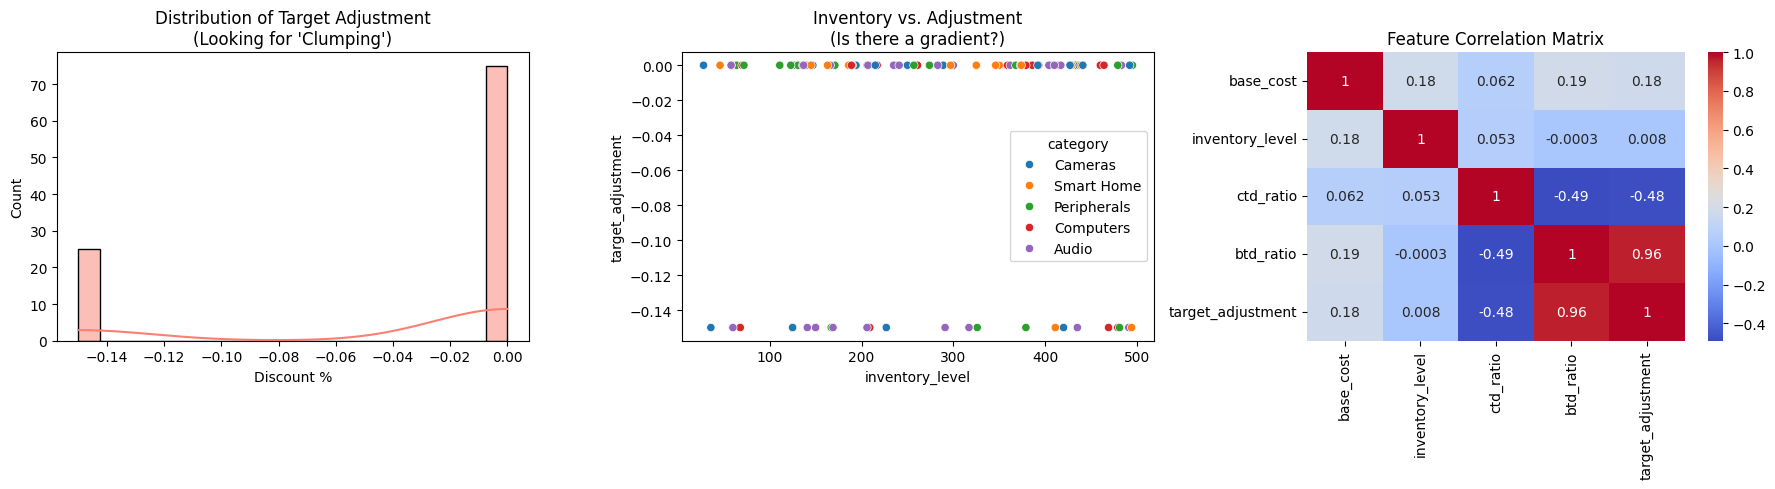

📊 DATA AUDIT:
Total Records: 100
Unique Target Values: 2
🚩 DIAGNOSIS: 'Binary Brain' confirmed. The data only has two states.


In [29]:
!pip install seaborn matplotlib pandas numpy -q
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_features is still in your memory from the ingestion cell
# If not, you can pull it from the Feature Store or S3
df = df_features.copy()

# Set up the visualization grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target Distribution (The "Smoking Gun")
sns.histplot(df['target_adjustment'], bins=20, kde=True, ax=axes[0], color='salmon')
axes[0].set_title("Distribution of Target Adjustment\n(Looking for 'Clumping')")
axes[0].set_xlabel("Discount %")

# 2. Inventory vs. Target (The "Logic Check")
sns.scatterplot(data=df, x='inventory_level', y='target_adjustment', hue='category', ax=axes[1])
axes[1].set_title("Inventory vs. Adjustment\n(Is there a gradient?)")

# 3. Correlation Heatmap (The "Feature Power")
# We only look at numeric columns
corr = df[['base_cost', 'inventory_level', 'ctd_ratio', 'btd_ratio', 'target_adjustment']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

# Print the stats to see how many unique values we have
unique_targets = df['target_adjustment'].nunique()
print(f"📊 DATA AUDIT:")
print(f"Total Records: {len(df)}")
print(f"Unique Target Values: {unique_targets}")
if unique_targets <= 2:
    print("🚩 DIAGNOSIS: 'Binary Brain' confirmed. The data only has two states.")
else:
    print("✅ DIAGNOSIS: Gradient detected. The model has a chance to learn nuance.")